In [ ]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.6 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Hn49rXIC9iN2cSuJUOH7")
project = rf.workspace("joseph-nelson").project("bccd")
version = project.version(4)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BCCD-4 in yolov8:: 100%|██████████| 1760/1760 [00:00<00:00, 9697.16it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=416,
    batch=16,
    patience=10,
    project="bccd_training",
    name="run1"
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BCCD-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [6]:
results = model.predict(
    source=f"{dataset.location}/test/images",
    conf=0.25,
    save=True
)
print("Predictions saved to:", results[0].save_dir)


image 1/36 /content/BCCD-4/test/images/BloodImage_00038_jpg.rf.ffa23e4b5b55b523367f332af726eae8.jpg: 416x416 2 Plateletss, 27 RBCs, 1 WBC, 8.7ms
image 2/36 /content/BCCD-4/test/images/BloodImage_00044_jpg.rf.e7760375eba4bc20c5746367e2311e18.jpg: 416x416 4 Plateletss, 20 RBCs, 2 WBCs, 6.3ms
image 3/36 /content/BCCD-4/test/images/BloodImage_00062_jpg.rf.1be1ca0ecdf783798fc10346baaa203e.jpg: 416x416 3 Plateletss, 18 RBCs, 1 WBC, 7.4ms
image 4/36 /content/BCCD-4/test/images/BloodImage_00090_jpg.rf.cdbf8f6ed3b93fa902a0bc991132cb40.jpg: 416x416 3 Plateletss, 18 RBCs, 1 WBC, 12.7ms
image 5/36 /content/BCCD-4/test/images/BloodImage_00099_jpg.rf.e3c42cd68359527494a53843479dff5c.jpg: 416x416 2 Plateletss, 18 RBCs, 1 WBC, 10.9ms
image 6/36 /content/BCCD-4/test/images/BloodImage_00112_jpg.rf.978cec39235980055c2ad7ff8b6f1912.jpg: 416x416 1 Platelets, 23 RBCs, 1 WBC, 33.4ms
image 7/36 /content/BCCD-4/test/images/BloodImage_00113_jpg.rf.a17463f1ddc2e7729f935f8a74bc86a4.jpg: 416x416 1 Platelets, 19 R

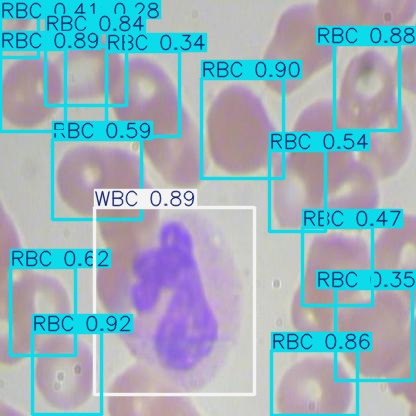

In [7]:
import glob
from IPython.display import Image, display

pred_imgs = glob.glob(f"{results[0].save_dir}/*.jpg")
display(Image(filename=pred_imgs[0]))